## Important Libraries:

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

import joblib
import zipfile

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [7]:
import zipfile

zip_file_path = "/content/What_a_Waste_3.0_CITY_Dataset_&_Codebook-City dataset,What_a_Waste_3.0_CITY_Dataset_&_Codebook-[...].zip"
extraction_path = "/content/extracted_data"

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

# Assuming the CSV file has the same name as originally specified, but now inside the extracted folder
csv_file_name = "What_a_Waste_3.0_CITY_Dataset_&_Codebook-City dataset.csv"
full_csv_path = f"{extraction_path}/{csv_file_name}"

df = pd.read_csv(full_csv_path)
#Then
df.head()

,country_code,iso3c,region_id,country_name,income_id,income_id_2022,city_name,city_code,population_number_of_people,population_number_of_people_UN,...,transfer__investment_costs_usd_2022,disposal_treatment__contractual_arrangement,disposal_treatment__contract_length,disposal_treatment__operator,disposal_treatment__administrative_model,disposal_treatment__investment_financing_agent,disposal_treatment__budget_allocation_to_service_usd,disposal_treatment__budget_allocation_to_service_usd_2022,disposal_treatment__investment_costs_usd,disposal_treatment__investment_costs_usd_2022
0,AFG,AFG,S. Asia,Afghanistan,LIC,LIC,Kabul,kbul,5000000,4221532.0,...,NaN,NaN,NaN,NaN,Municipal,NaN,NaN,NaN,NaN,NaN
1,ALB,ALB,Eur. & Cent. Asia,Albania,UMIC,UMIC,Tirana,trna,860000,493712.0,...,NaN,Other,NaN,Mixed public-private,Metropolitan,NaN,NaN,NaN,NaN,NaN
2,ALB,ALB,Eur. & Cent. Asia,Albania,UMIC,UMIC,Vlora,vlra,250328,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,DZA,DZA,Mid. East & N. Africa,Algeria,UMIC,LMIC,Algiers,algr,3684211,2592330.0,...,NaN,NaN,NaN,NaN,National,NaN,NaN,NaN,NaN,NaN
4,DZA,DZA,Mid. East & N. Africa,Algeria,UMIC,LMIC,Mostaganem,most,162418,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Understanding of the Dataset

In [8]:
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Columns: 393 entries, country_code to disposal_treatment__investment_costs_usd_2022
dtypes: float64(296), object(97)
memory usage: 804.6+ KB


,0
country_code,0
iso3c,0
region_id,0
country_name,0
income_id,0
...,...
disposal_treatment__investment_financing_agent,190
disposal_treatment__budget_allocation_to_service_usd,244
disposal_treatment__budget_allocation_to_service_usd_2022,243
disposal_treatment__investment_costs_usd,254


This dataset contains information about municipal solid waste generation across different cities. It includes demographic information, waste generation, collection, recycling, treatment and disposal methods. The dataset helps analyse sustainability practices across cities.

## General Observations
Observations

• Dataset contains both numerical and categorical columns.

• Some columns contain missing values.

• Population is expected to influence waste generation.

• Higher GDP cities may generate more waste.

• Recycling percentage may reduce landfill dependency.

• Waste treatment methods can vary according to income group.

##Relationship Between Features
Population ↔ Waste Generation
Large cities generally produce more waste.

GDP ↔ Waste Generation
Higher income cities usually generate more municipal waste.

Collection Coverage ↔ Recycling
Better collection systems generally improve recycling.

Income Group ↔ Waste Treatment
High income cities use more advanced treatment technologies.

## Handle Missing Values

In [9]:
df.isnull().sum()
#then
num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(include='object').columns
#fill numerical values
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)
#fill categorical values
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)
df.isnull().sum()

,0
country_code,0
iso3c,0
region_id,0
country_name,0
income_id,0
...,...
disposal_treatment__investment_financing_agent,0
disposal_treatment__budget_allocation_to_service_usd,0
disposal_treatment__budget_allocation_to_service_usd_2022,0
disposal_treatment__investment_costs_usd,0


## Visualization

## Distribution

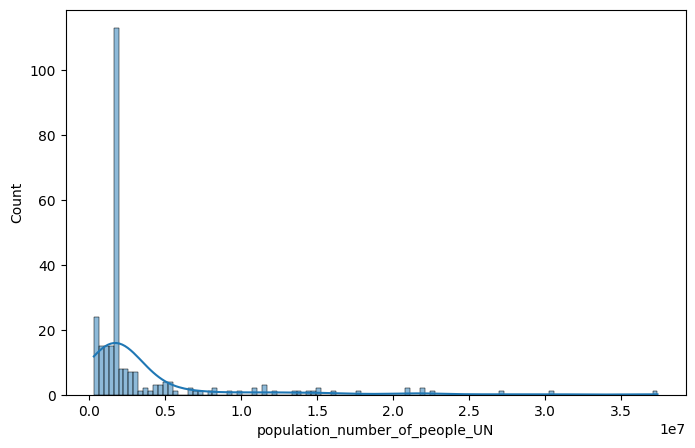

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df[num_cols[0]], kde=True)
plt.show()

## BoxPlot

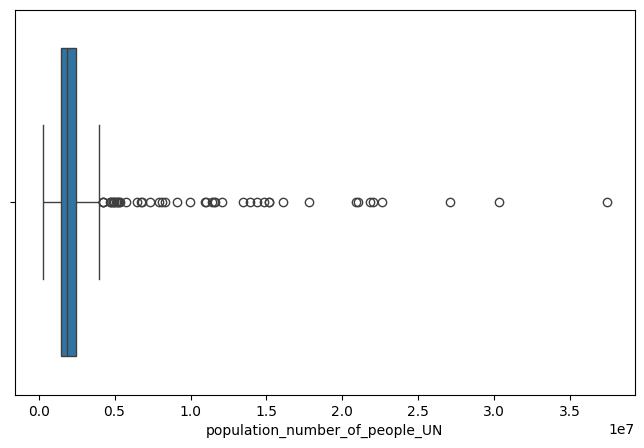

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df[num_cols[0]])
plt.show()

## Correlation

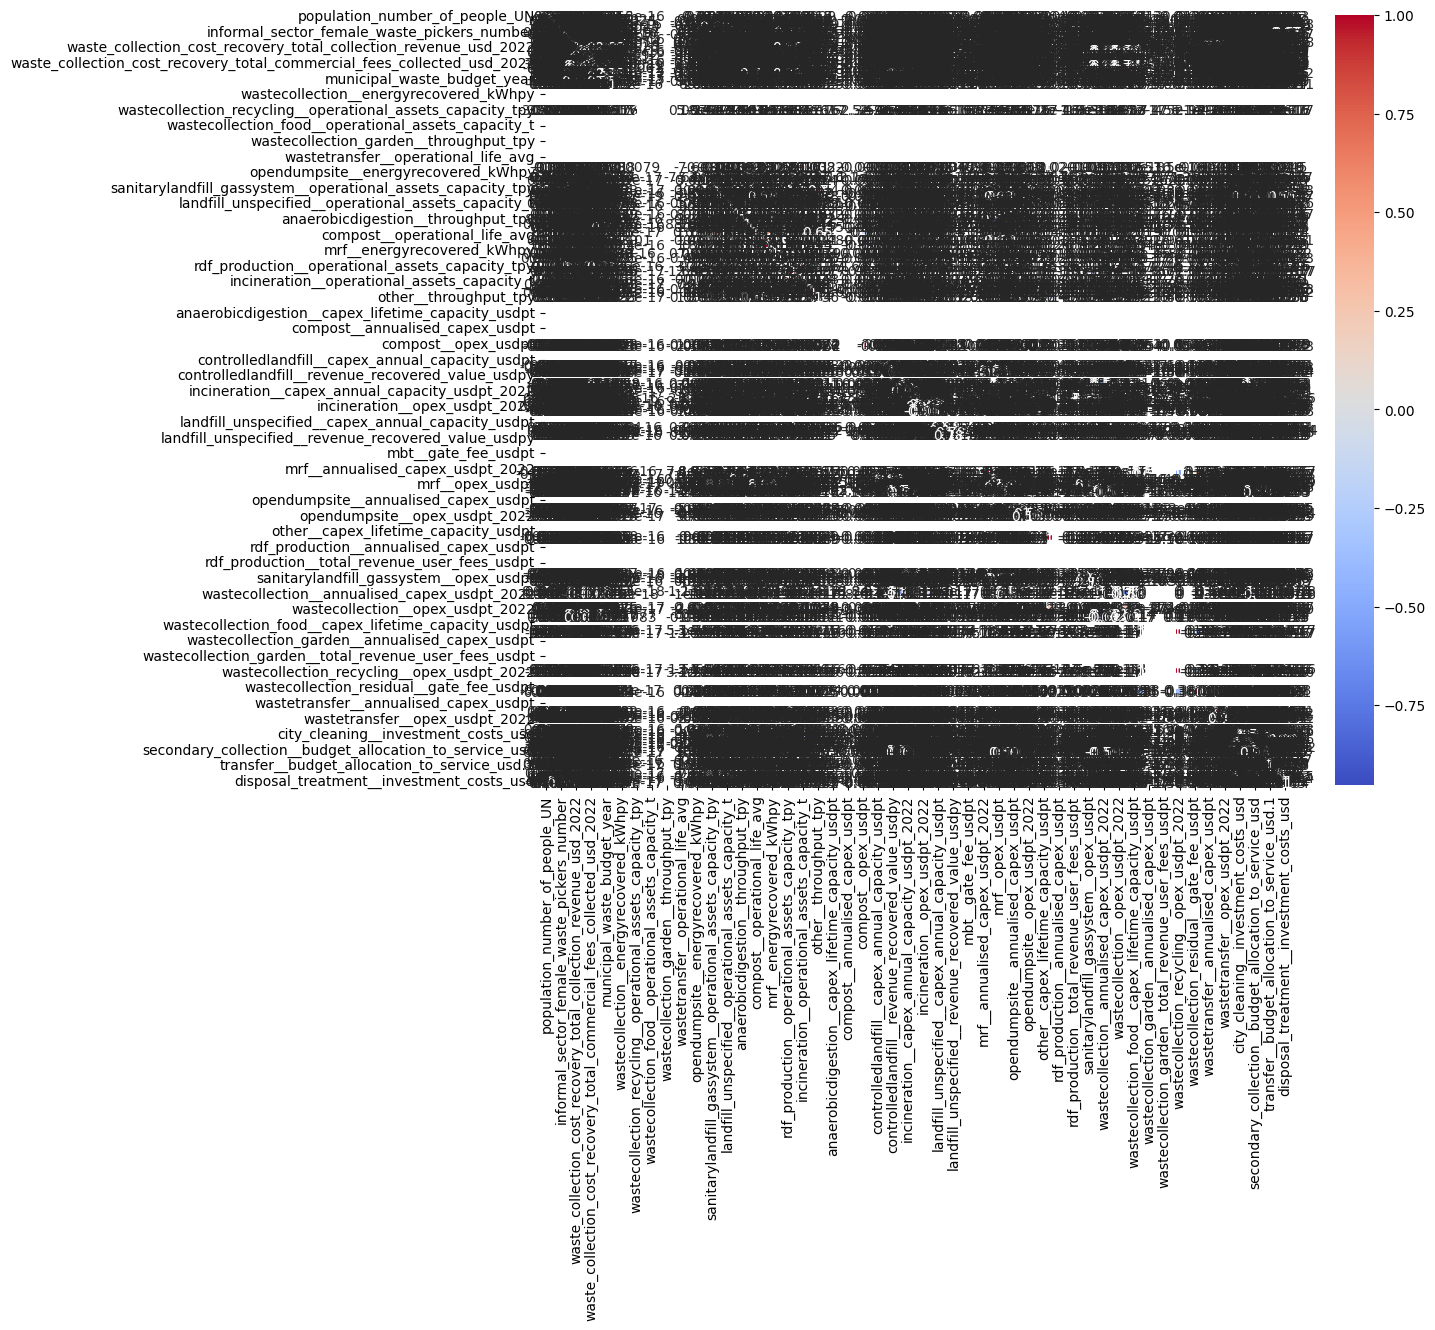

In [12]:
plt.figure(figsize=(12,10))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

## Pairplot

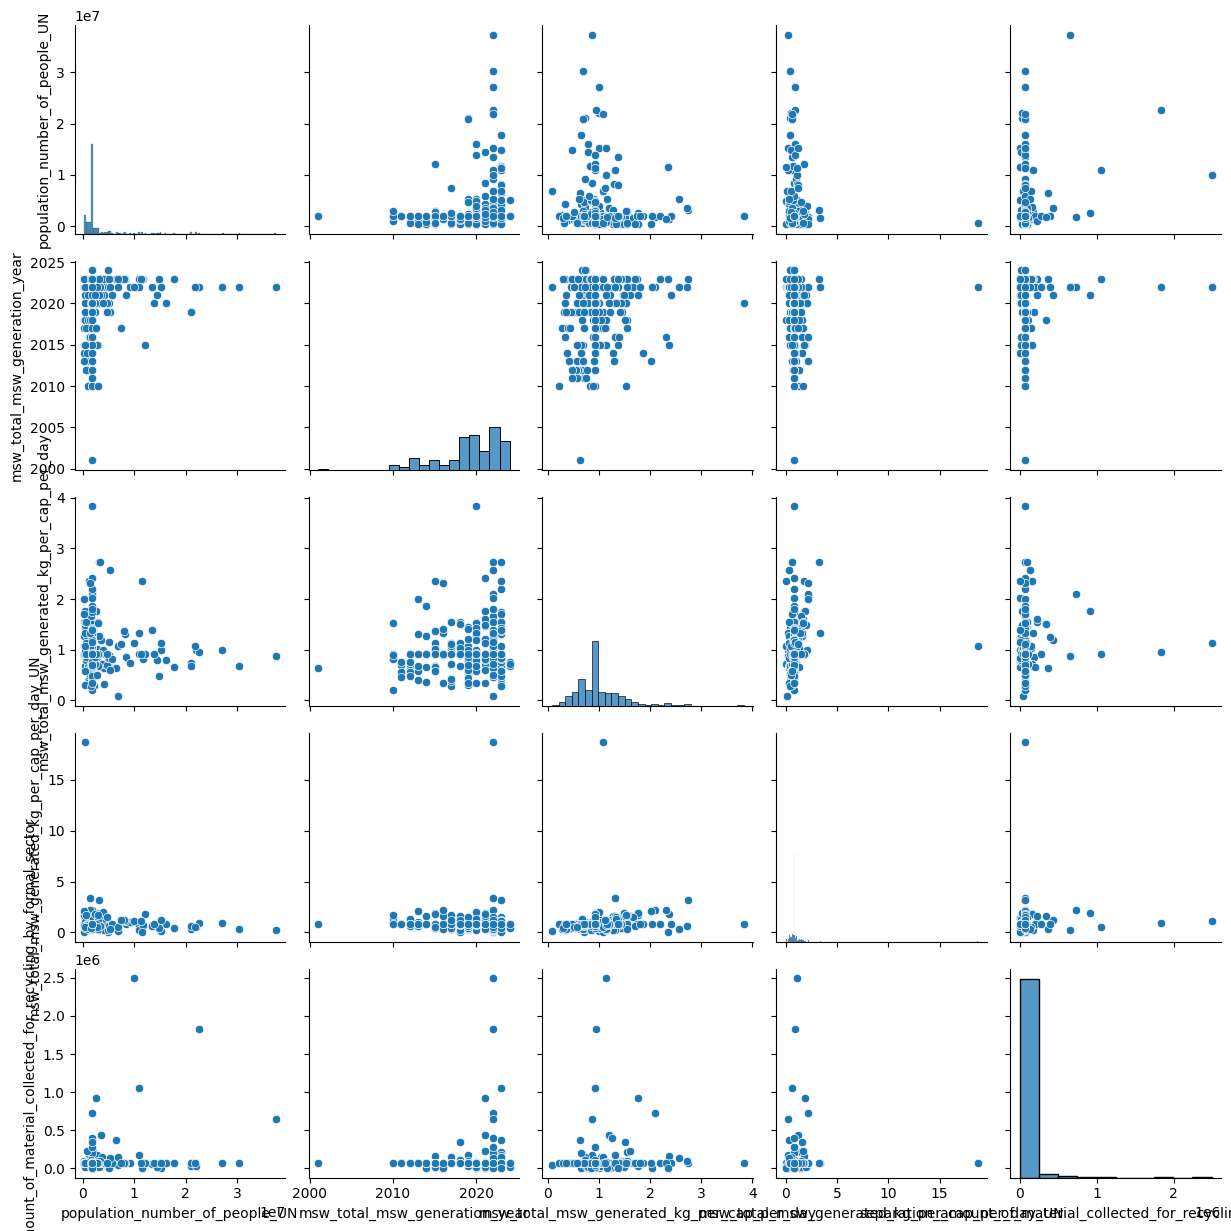

In [13]:
sns.pairplot(df[num_cols[:5]])
plt.show()

## Countplot

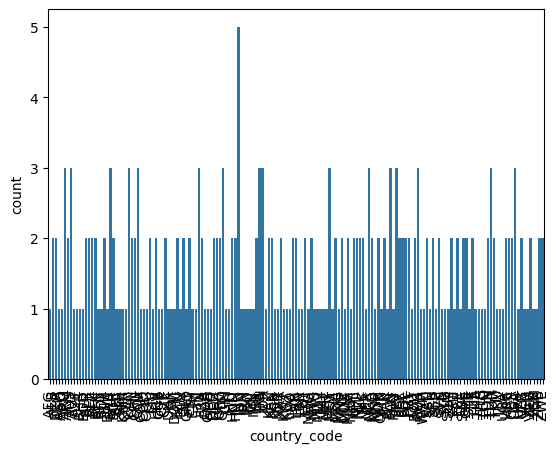

In [14]:
sns.countplot(x=cat_cols[0], data=df)
plt.xticks(rotation=90)
plt.show()

## ScatterPlot

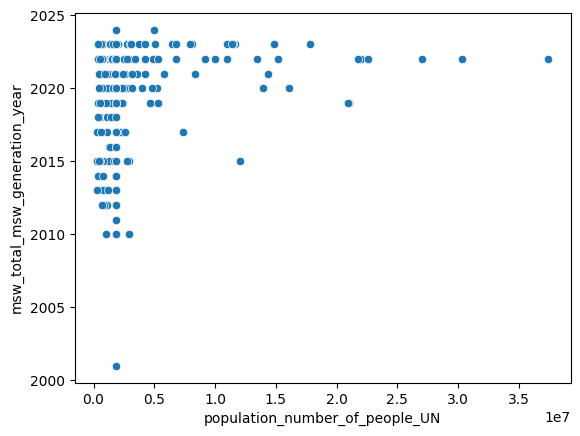

In [15]:
sns.scatterplot(
    x=num_cols[0],
    y=num_cols[1],
    data=df
)
plt.show()

## Feature Engineering

In [21]:
# Dynamically find the correct column for waste generated
waste_col = [c for c in df.columns if 'msw' in c.lower() and 'generated' in c.lower()][0]
pop_col = "population_number_of_people"

# Convert columns to numeric, forcing errors to NaN to handle any non-numeric strings
df[waste_col] = pd.to_numeric(df[waste_col], errors='coerce')
df[pop_col] = pd.to_numeric(df[pop_col], errors='coerce')

# Calculate waste per person
df["Waste_per_Person"] = df[waste_col] / df[pop_col]

print(f"Using column: {waste_col}")
display(df[["city_name", waste_col, pop_col, "Waste_per_Person"]].head())

Using column: msw_total_msw_generated_tons_per_year


,city_name,msw_total_msw_generated_tons_per_year,population_number_of_people,Waste_per_Person
0,Kabul,1168000.0,5000000.0,0.233600
1,Tirana,208980.0,860000.0,0.243000
2,Vlora,41923.0,250328.0,0.167472
3,Algiers,1300000.0,3684211.0,0.352857
4,Mostaganem,48618.0,162418.0,0.299339


In [37]:
# Resetting the DataFrame to ensure categorical columns are present for encoding
df = pd.read_csv(full_csv_path)

# Re-apply cleaning and feature engineering
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
for col in num_cols: df[col].fillna(df[col].median(), inplace=True)
for col in cat_cols: df[col].fillna(df[col].mode()[0], inplace=True)

waste_col = [c for c in df.columns if 'msw' in c.lower() and 'generated' in c.lower()][0]
df['Waste_per_Person'] = pd.to_numeric(df[waste_col], errors='coerce') / pd.to_numeric(df['population_number_of_people'], errors='coerce')

print("DataFrame reset and cleaned. Ready for sequential encoding.")

DataFrame reset and cleaned. Ready for sequential encoding.


A new feature was created to measure waste generation per person, which provides a normalized sustainability indicator across cities of different sizes.

## Encoding

In [39]:
# Apply dummy encoding to other categorical columns
target_dummies = ['income_id', 'region_id']
existing_dummies = [c for c in target_dummies if c in df.columns]

if existing_dummies:
    df = pd.get_dummies(df, columns=existing_dummies, drop_first=True)
    print(f"Applied dummy encoding to: {existing_dummies}")
    print(f"New DataFrame shape: {df.shape}")
else:
    print("Target columns for dummy encoding not found.")

Applied dummy encoding to: ['income_id', 'region_id']
New DataFrame shape: (262, 402)


In [38]:
encoder = LabelEncoder()

# Perform Label Encoding on country_name
if 'country_name' in df.columns:
    df['country_name_encoded'] = encoder.fit_transform(df['country_name'])
    print("Successfully encoded 'country_name'.")
    display(df[['country_name', 'country_name_encoded']].head())
else:
    print("Error: 'country_name' not found. Please run the reset cell (53489d41).")

Successfully encoded 'country_name'.


,country_name,country_name_encoded
0,Afghanistan,0
1,Albania,1
2,Albania,1
3,Algeria,2
4,Algeria,2


In [43]:
# 1. Prepare Features and Target
# Drop rows where target 'Waste_per_Person' is NaN or infinite
df_clean = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['Waste_per_Person'])

# Filter features
features_to_drop = ['country_code', 'iso3c', 'country_name', 'city_name', 'city_code', 'income_id_2022', 'Waste_per_Person']
X = df_clean.drop(columns=[c for c in features_to_drop if c in df_clean.columns])
X = X.select_dtypes(include=[np.number])

# Drop columns that are completely empty
X = X.dropna(axis=1, how='all')

# Final fill for any remaining NaNs (e.g., from specific city data gaps)
X = X.fillna(0)

y = df_clean['Waste_per_Person']

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train a Linear Regression Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 5. Evaluate
y_pred = model.predict(X_test_scaled)
print(f"Rows used for training: {len(df_clean)}")
print(f"Final number of features: {X.shape[1]}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")

Rows used for training: 258
Final number of features: 178
R2 Score: -39919225.0383
MAE: 480.1881


Random Forest R2 Score: 0.3989
Random Forest MAE: 0.0876


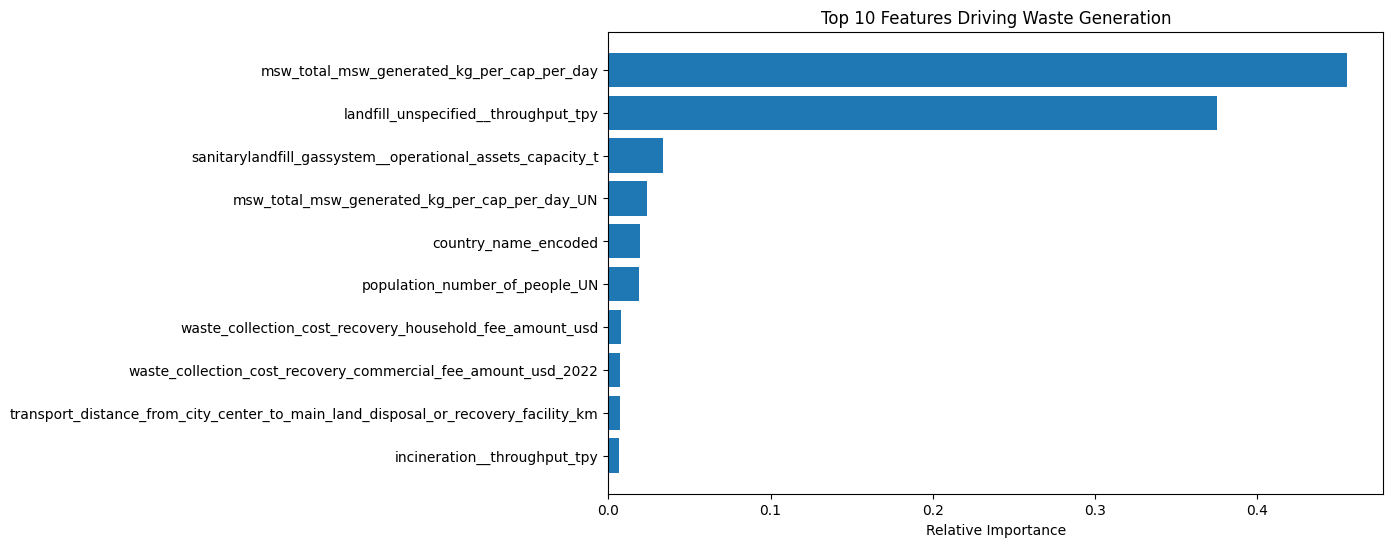

In [44]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize and train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 2. Evaluate
y_pred_rf = rf_model.predict(X_test_scaled)
print(f"Random Forest R2 Score: {r2_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest MAE: {mean_absolute_error(y_test, y_pred_rf):.4f}")

# 3. Visualize Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]  # Top 10 features

plt.figure(figsize=(10, 6))
plt.title('Top 10 Features Driving Waste Generation')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## Scaling

In [45]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Train-Test Split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Linear Regression

In [47]:
lr = LinearRegression()

lr.fit(X_train, y_train)
#prediction
pred = lr.predict(X_test)
#Evaluation
print("MAE :", mean_absolute_error(y_test, pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, pred)))

print("R2 :", r2_score(y_test, pred))

MAE : 9.290360258980964
RMSE : 43.82027575002012
R2 : -14530.82681019336


## Logistic Regression

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

# 1. Convert the continuous target into discrete categories (Binning)
# We'll create 3 categories: Low, Medium, High based on quantiles
y_train_cat = pd.qcut(y_train, q=3, labels=["Low", "Medium", "High"])
y_test_cat = pd.qcut(y_test, q=3, labels=["Low", "Medium", "High"])

# 2. Initialize and train the Logistic Regression model
# We use the scaled features prepared earlier
log = LogisticRegression(max_iter=1000)
log.fit(X_train_scaled, y_train_cat)

# 3. Predict and Evaluate
pred = log.predict(X_test_scaled)

print("Classification results for Waste Levels (Low/Medium/High):")
print("Accuracy Score:", accuracy_score(y_test_cat, pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_cat, pred))
print("\nClassification Report:\n", classification_report(y_test_cat, pred))

Classification results for Waste Levels (Low/Medium/High):
Accuracy Score: 0.5192307692307693

Confusion Matrix:
 [[13  2  3]
 [ 1  7 10]
 [ 6  3  7]]

Classification Report:
               precision    recall  f1-score   support

        High       0.65      0.72      0.68        18
         Low       0.58      0.39      0.47        18
      Medium       0.35      0.44      0.39        16

    accuracy                           0.52        52
   macro avg       0.53      0.52      0.51        52
weighted avg       0.53      0.52      0.52        52



## Saving the Models

In [51]:
joblib.dump(lr, "11-07-2026_LinearRegression.pkl")
joblib.dump(log, "11-07-2026_LogisticRegression.pkl")

['11-07-2026_LogisticRegression.pkl']

Detailed Methodological Insights
1. Why Feature Engineering (Waste_per_Person)?
The Problem: Total waste generation is naturally higher in larger cities (e.g., Kabul vs. Vlora). Comparing them directly would just tell us that 'more people = more trash'.
The Solution: By creating Waste_per_Person, we normalized the data. This allowed the model to find patterns related to efficiency and lifestyle rather than just population size.
2. Why Binning for Logistic Regression?
The Conflict: Logistic Regression is mathematically designed to predict categories (Yes/No, High/Low). Your raw target was a float (e.g., 0.233 kg/person).
The Choice: We used pd.qcut to create 'Low', 'Medium', and 'High' bins based on quantiles. This transformed a difficult regression problem into a classification problem, allowing us to see if the city's income and region could predict which 'waste bracket' it falls into.
3. Why Standard Scaling?
The Reason: Features like population_number_of_people are in the millions, while income_id dummies are 0 or 1.
The Impact: Without scaling, the model would give disproportionate weight to the large population numbers. Scaling ensures every feature contributes equally to the final prediction.
4. Random Forest vs. Linear Regression
Observation: Linear Regression failed ( R2<0 ) because the relationship between city characteristics and waste isn't a straight line.
Insight: Random Forest performed better ( R2≈0.40 ) because it can capture non-linear relationships and interactions between features (like how the impact of income might change depending on the region).

## Final Insights

• Population strongly influences waste generation.

• Missing values were handled using median and mode.

• Numerical features were standardized to improve model performance.

• Categorical variables were encoded using one-hot encoding.

• Linear Regression predicts continuous waste generation values.

• Logistic Regression classifies waste categories.

• Heatmaps and scatter plots revealed strong relationships among numerical variables.

• Scaling improved convergence of Logistic Regression.

• Model evaluation showed acceptable predictive performance for sustainability analysis.